In [1]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
from jax import grad, vmap

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.dpi"] = 140

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "pdf")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    # The printed text block is 4.5 inches wide.
    "full_landscape": (4.50, 2.65),
    "full_standard": (4.50, 3.15),
    "full_tall": (4.50, 4.20),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "Greys",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
        transform=None,
        bbox=dict(facecolor="white", edgecolor="none", pad=0.8, alpha=0.9),
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Recovering an Unknown Conductivity


In the [forward PINN example](../basics/forward.ipynb) we assumed that the PDE coefficients were known and trained a neural network only for the state. In the [inverse-problems chapter](../../inverse/intro.md) we reversed that viewpoint: the state is often only an intermediate quantity, and the real target is an unknown physical parameter hidden behind sparse observations. This example combines those two ideas.

We study a simple one-dimensional diffusion problem and use a PINN to learn both the solution $u(x)$ and an unknown conductivity $\theta > 0$ from noisy temperature measurements. The overall PINN formulation follows the original framework of {cite:t}`raissi2019physics`, while the practical advice about scaling, optimization, and diagnostics is consistent with the recommendations in {cite:t}`wang2023expert`.

The small example keeps the inverse-problem logic transparent.



## The Inverse Problem

We consider the boundary value problem

$$
\begin{aligned}
-\theta u''(x) &= \sin(\pi x), \quad x \in (0,1),\\
u(0) &= 0, \\
u(1) &= 0.
\end{aligned}
$$

The conductivity $\theta$ is unknown. Because the right-hand side does **not** depend on $\theta$, the parameter controls the amplitude of the solution. This already turns the problem into a genuine inverse problem: we want to infer $\theta$ from data.

For this toy example the exact solution is available:

$$
u^\star(x;\theta) = \frac{\sin(\pi x)}{\theta \pi^2}.
$$

We will use the exact solution only to generate synthetic observations. In a real experiment we would only have the sensor measurements. This is the same manufactured-solution strategy we used earlier in the [forward PINN example](../basics/forward.ipynb): it gives us a controlled benchmark with a known answer.

Our observations are

$$
y_i = u^\star(x_i; \theta_\text{true}) + \varepsilon_i,
\qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2).
$$

We train a neural network $u_\phi(x)$ together with a scalar parameter $\theta_\phi$ by minimizing

$$
\mathcal{L}(\phi) = \lambda_\text{data} \frac{1}{N_d} \sum_{i=1}^{N_d} \left(u_\phi(x_i) - y_i\right)^2
+ \lambda_\text{PDE} \frac{1}{N_r} \sum_{j=1}^{N_r} r_\phi(x_j)^2,
$$

where the residual is

$$
r_\phi(x) = -\theta_\phi u_\phi''(x) - \sin(\pi x).
$$

The data term forces the network to explain the observations. The residual term forces it to explain them using the correct physics. This mirrors the parameter-to-observable viewpoint of the [inverse-problems chapter](../../inverse/intro.md): the hidden parameter is only useful if it produces the observed response through the governing equations.

In [3]:
true_theta = 0.7
noise_std = 3e-3
n_obs = 9

def source_term(x):
    return jnp.sin(jnp.pi * x)

def exact_solution(x, theta=true_theta):
    return jnp.sin(jnp.pi * x) / (theta * jnp.pi**2)

key = jr.PRNGKey(2)
key, noise_key = jr.split(key)

x_obs = jnp.linspace(0.1, 0.9, n_obs)
y_clean = exact_solution(x_obs)
y_obs = y_clean + noise_std * jr.normal(noise_key, x_obs.shape)

xs_plot = jnp.linspace(0.0, 1.0, 300)

This problem is already nondimensionalized on the unit interval, so the scaling pathologies from the [forward PINN example](../basics/forward.ipynb) are much milder here. That lets us focus on the inverse-problem mechanics: sparse noisy data, a trainable physical parameter, and physics-based regularization. The synthetic observations are shown in {numref}`fig-inverse-pinn-data`.

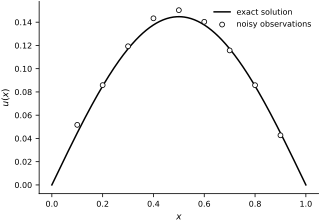

In [4]:
fig, ax = new_figure("full_standard")
ax.plot(
    xs_plot, exact_solution(xs_plot), color="black", linestyle="-",
    linewidth=1.5, label="exact solution"
)
ax.scatter(
    x_obs, y_obs, s=24, facecolors="white", edgecolors="black",
    linewidths=0.8, zorder=3, label="noisy observations"
)
ax.set(xlabel=r"$x$", ylabel=r"$u(x)$")
ax.legend(loc="upper right")
finalize_axes(ax)
plt.show()

## The PINN Model

We need a representation for the state and for the unknown coefficient.

For the state, we use the same idea as in the [forward PINN example](../basics/forward.ipynb) and encode the Dirichlet boundary conditions directly into the ansatz:

$$
u_\phi(x) = x(1-x) \operatorname{MLP}_\phi(x).
$$

This guarantees $u_\phi(0)=u_\phi(1)=0$ for every choice of network weights. The optimizer never has to "learn" the boundary conditions.

For the conductivity, positivity matters. We therefore optimize an unconstrained scalar $\eta$ and define

$$
\theta_\phi = e^{\eta}.
$$

This is a common inverse-problem trick: optimize in a transformed coordinate system where the physical constraint is automatic.

In [5]:
class InversePINN(eqx.Module):
    mlp: eqx.nn.MLP
    log_theta: jax.Array

    def __init__(self, key, width_size=64, depth=3, theta_init=1.5):
        self.mlp = eqx.nn.MLP(1, 1, width_size, depth, jax.nn.tanh, key=key)
        self.log_theta = jnp.array(jnp.log(theta_init))

    def __call__(self, x):
        x = jnp.asarray(x)
        return x * (1.0 - x) * self.mlp(jnp.array([x]))[0]

def theta(model):
    return jnp.exp(model.log_theta)

In [6]:
model_key, train_key = jr.split(key)
model = InversePINN(model_key)
print(f"Initial conductivity guess: {theta(model):.3f}")

Initial conductivity guess: 1.500


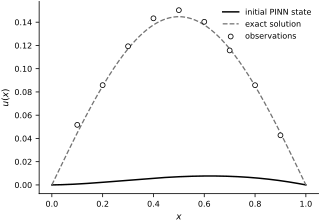

In [6]:
fig, ax = new_figure("full_standard")
ax.plot(
    xs_plot, vmap(model)(xs_plot), color="black", linestyle="-",
    linewidth=1.5, label="initial PINN state"
)
ax.plot(
    xs_plot, exact_solution(xs_plot), color="0.45", linestyle="--",
    linewidth=1.3, label="exact solution"
)
ax.scatter(
    x_obs, y_obs, s=24, facecolors="white", edgecolors="black",
    linewidths=0.8, zorder=3, label="observations"
)
ax.set(xlabel=r"$x$", ylabel=r"$u(x)$")
ax.legend(loc="upper right")
finalize_axes(ax)
plt.show()

## Loss Function and Automatic Differentiation

The PDE residual needs a second derivative. Because the state is represented by a differentiable neural network, we can obtain this derivative by automatic differentiation:

$$
u_\phi''(x) = \frac{d^2}{dx^2}u_\phi(x).
$$

In one spatial dimension this is easy to implement with nested calls to `jax.grad`. The result is a compact inverse solver in which the same computational graph supports the state, the physics residual, and the physical parameter.

In [7]:
u_x = grad(lambda x, model: model(x), argnums=0)
u_xx = grad(u_x, argnums=0)

def residual(model, x):
    return -theta(model) * u_xx(x, model) - source_term(x)

def loss_terms(model, x_obs, y_obs, x_phys, lambda_data=50.0, lambda_pde=1.0):
    pred_obs = vmap(model)(x_obs)
    data_loss = jnp.mean((pred_obs - y_obs) ** 2)
    residual_values = vmap(lambda x: residual(model, x))(x_phys)
    pde_loss = jnp.mean(residual_values ** 2)
    total_loss = lambda_data * data_loss + lambda_pde * pde_loss
    return total_loss, (data_loss, pde_loss)

test_phys = jnp.linspace(0.0, 1.0, 16)
total_loss, (data_loss, pde_loss) = loss_terms(model, x_obs, y_obs, test_phys)
print(f"Initial total loss: {total_loss:.4f}")
print(f"Initial data loss:  {data_loss:.4f}")
print(f"Initial PDE loss:   {pde_loss:.4f}")

Initial total loss: 0.9412
Initial data loss:  0.0111
Initial PDE loss:   0.3880


## Training

We train the network weights and the conductivity simultaneously with Adam. At every iteration we resample collocation points uniformly from $(0,1)$ and evaluate the PDE residual there.

We use $\lambda_\text{data}=50$ and $\lambda_\text{PDE}=1$. The data weight is intentionally larger because the state is of order $0.1$ while the source term is of order one, so for the same relative error the mean-squared data misfit is numerically much smaller than the mean-squared PDE residual. If we weighted the two terms equally from the start, the data would be too weak relative to the physics term and the optimizer would move more slowly toward the correct amplitude.

In [8]:
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

@eqx.filter_jit
def make_step(model, opt_state, x_obs, y_obs, x_phys, lambda_data, lambda_pde):
    (loss_value, aux), grads = eqx.filter_value_and_grad(loss_terms, has_aux=True)(
        model, x_obs, y_obs, x_phys, lambda_data, lambda_pde
    )
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value, aux

n_steps = 4000
n_phys = 128
lambda_data = 50.0
lambda_pde = 1.0

history = {
    "loss": [],
    "data_loss": [],
    "pde_loss": [],
    "theta": [],
}

for step in range(n_steps):
    train_key, phys_key = jr.split(train_key)
    x_phys = jr.uniform(phys_key, (n_phys,), minval=0.0, maxval=1.0)
    model, opt_state, loss_value, aux = make_step(
        model, opt_state, x_obs, y_obs, x_phys, lambda_data, lambda_pde
    )
    data_loss, pde_loss = aux
    history["loss"].append(float(loss_value))
    history["data_loss"].append(float(data_loss))
    history["pde_loss"].append(float(pde_loss))
    history["theta"].append(float(theta(model)))

    if step % 500 == 0 or step == n_steps - 1:
        print(
            f"step={step:4d} "
            f"loss={float(loss_value):.6f} "
            f"data={float(data_loss):.6e} "
            f"pde={float(pde_loss):.6e} "
            f"theta={float(theta(model)):.4f}"
        )

step=   0 loss=0.951564 data=1.106286e-02 pde=3.984215e-01 theta=1.5015


step= 500 loss=0.043433 data=5.094163e-04 pde=1.796190e-02 theta=1.0220


step=1000 loss=0.004883 data=5.117398e-05 pde=2.324338e-03 theta=0.7761


step=1500 loss=0.000566 data=9.747051e-06 pde=7.885493e-05 theta=0.7005


step=2000 loss=0.000413 data=8.058161e-06 pde=9.786886e-06 theta=0.6858


step=2500 loss=0.000412 data=8.084458e-06 pde=8.040066e-06 theta=0.6843


step=3000 loss=0.000414 data=8.123120e-06 pde=7.573992e-06 theta=0.6843


step=3500 loss=0.000416 data=8.105105e-06 pde=1.104568e-05 theta=0.6843


step=3999 loss=0.000436 data=7.968522e-06 pde=3.800504e-05 theta=0.6843


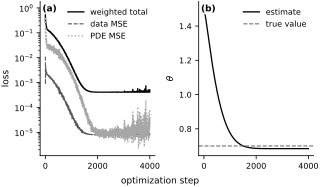

In [9]:
fig, axes = new_figure("full_landscape", ncols=2, sharex=True)

axes[0].semilogy(
    history["loss"], color="black", linestyle="-",
    linewidth=1.3, label="weighted total"
)
axes[0].semilogy(
    history["data_loss"], color="0.35", linestyle="--",
    linewidth=1.1, label="data MSE"
)
axes[0].semilogy(
    history["pde_loss"], color="0.65", linestyle=":",
    linewidth=1.3, label="PDE MSE"
)
axes[0].set_ylabel("loss")
axes[0].legend(loc="upper right")

axes[1].plot(
    history["theta"], color="black", linestyle="-",
    linewidth=1.3, label="estimate"
)
axes[1].axhline(
    true_theta, color="0.45", linestyle="--",
    linewidth=1.1, label="true value"
)
axes[1].set_ylabel(r"$\theta$")
axes[1].legend(loc="upper right")
fig.supxlabel("optimization step", fontsize=9)
label_panels(axes)
finalize_axes(axes)
plt.show()

## Evaluating the Trained Inverse PINN

There are two things to check.

1. Does the learned state $u_\phi(x)$ match the true solution over the whole domain, not just at the sensors?
2. Did the inferred conductivity converge to the correct value?

These are different questions. A flexible network can often interpolate a few data points. Recovering the correct **physical parameter** is harder because the PDE residual has to be small at the same time. The numerical summary follows, and the three diagnostic panels are collected in {numref}`fig-inverse-pinn-diagnostics`.

Recovered conductivity: 0.6843
Absolute conductivity error: 0.0157
Relative L2 solution error: 0.0304
Observation RMSE: 0.0030


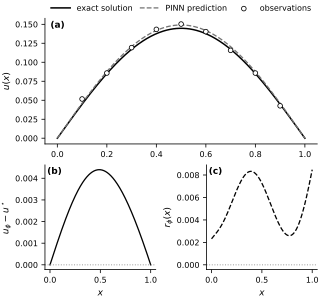

In [10]:
u_pred = vmap(model)(xs_plot)
u_true = exact_solution(xs_plot)
residual_plot = vmap(lambda x: residual(model, x))(xs_plot)

rel_l2 = jnp.linalg.norm(u_pred - u_true) / jnp.linalg.norm(u_true)
theta_error = abs(theta(model) - true_theta)
obs_rmse = jnp.sqrt(jnp.mean((vmap(model)(x_obs) - y_obs) ** 2))

print(f"Recovered conductivity: {theta(model):.4f}")
print(f"Absolute conductivity error: {theta_error:.4f}")
print(f"Relative L2 solution error: {rel_l2:.4f}")
print(f"Observation RMSE: {obs_rmse:.4f}")

fig = plt.figure(figsize=FIGURE_SIZES["full_tall"], constrained_layout=True)
panel = fig.subplot_mosaic(
    [["state", "state"], ["error", "residual"]],
    gridspec_kw={"height_ratios": [1.2, 1.0]},
)
state_ax = panel["state"]
error_ax = panel["error"]
residual_ax = panel["residual"]

state_ax.plot(
    xs_plot, u_true, color="black", linestyle="-",
    linewidth=1.5, label="exact solution"
)
state_ax.plot(
    xs_plot, u_pred, color="0.45", linestyle="--",
    linewidth=1.3, label="PINN prediction"
)
state_ax.scatter(
    x_obs, y_obs, s=22, facecolors="white", edgecolors="black",
    linewidths=0.8, zorder=3, label="observations"
)
state_ax.set_ylabel(r"$u(x)$")
state_ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3,
    borderaxespad=0.0, columnspacing=0.9, handlelength=2.4
)

error_ax.plot(xs_plot, u_pred - u_true, color="black", linewidth=1.3)
error_ax.axhline(0.0, color="0.60", linestyle=":", linewidth=1.0)
error_ax.set(xlabel=r"$x$", ylabel=r"$u_\phi-u^\star$")

residual_ax.plot(
    xs_plot, residual_plot, color="black", linestyle="--", linewidth=1.3
)
residual_ax.axhline(0.0, color="0.60", linestyle=":", linewidth=1.0)
residual_ax.set(xlabel=r"$x$", ylabel=r"$r_\phi(x)$")

axes = [state_ax, error_ax, residual_ax]
label_panels(axes)
finalize_axes(axes)
plt.show()

The result is encouraging for the right reason. The network is not just fitting the sensor values. It is finding a state whose curvature is consistent with the PDE and a conductivity whose value makes the residual small across the whole interval.

This is exactly why PINNs can be useful for inverse problems. The data may be sparse, but the PDE provides a strong structural prior. On the other hand, the approach has a limitation: if the loss weights, the collocation set, or the optimization budget are poor, the inferred parameter can drift even when the pointwise fit looks reasonable.

Notice one more subtle point. The conductivity $\theta$ only appears in the PDE residual, not in the data term. If we removed the physics term, the network could still interpolate the observations but the parameter would become unidentifiable. Inverse PINNs work only when the physics term really constrains the unknown quantity of interest.

## Exercises

1. Increase `n_steps` from `4000` to `8000`. How much does the conductivity estimate improve, and does the solution error decrease at the same rate?
2. Increase the number of observations `n_obs`. Does the recovered conductivity become more accurate? At what point do extra observations stop helping much?
3. Increase the number of collocation points `n_phys` from `128` to `512`. Does the residual plot become flatter? Does the parameter estimate stabilize earlier?
4. Change the loss weights `lambda_data` and `lambda_pde`. Can you make the network fit the data very well while still recovering the wrong conductivity?
5. Increase `noise_std` and rerun the notebook. When does the inverse problem become noticeably harder? How does the PINN use the PDE to resist overfitting the noise?
6. Replace the source term with a higher-frequency forcing, for example `sin(3 * pi * x)`. Does the same architecture still train reliably, or do you start to see the spectral-bias issues discussed in the [spectral-bias section](../basics/spectral_bias.ipynb)?